# **CIFO Project 25/26 - Challenge**

In this notebook, we'll develop a Hill Climbing variation to generate a minimalist version of *Girl with a Pearl Earring* by Johannes Vermeer.

# Imports

In [1]:
!rm -rf CIFO_NovaIMS_25-26/  #To run if we change things online

In [2]:
# We need to clone the repository to acess the data and the code in colab
!git clone https://github.com/isasofesteves/CIFO_NovaIMS_25-26.git

Cloning into 'CIFO_NovaIMS_25-26'...
remote: Enumerating objects: 165, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 165 (delta 12), reused 0 (delta 0), pack-reused 141 (from 1)
Receiving objects: 100% (165/165), 2.75 MiB | 26.10 MiB/s, done.
Resolving deltas: 100% (82/82), done.


In [3]:
%pip install cupy-cuda12x

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Data Manipulation & Scientific Computing
import numpy as np
from sklearn.cluster import KMeans
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
from itertools import combinations

# Visualization & Plotting
import matplotlib.pyplot as plt

# Image Processing
from PIL import Image
import seaborn as sns

# System & File Management
import os
import sys
sys.path.insert(0, './CIFO_NovaIMS_25-26/') # Set the path to the cloned repository
import importlib

# Logic, Structure & Functional Tools
import random
from functools import partial

# Custom Module Imports & Path Configuration
sys.path.append('')


import func_py_optimized_numba
importlib.reload(func_py_optimized_numba)

from func_py_optimized_numba import *

print("Imports OK")

Imports OK


In [5]:
# Check the functions in python_func.py
print("Available functions in python_func.py:")
print(dir(sys.modules['func_py_optimized_numba']))

Available functions in python_func.py:
['DEVICE', 'IMG_H', 'IMG_W', 'Image', 'ImageDraw', 'ImageFilter', 'NUM_TRIANGLES', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '_clamp', 'alpha_focus_mutation', 'apply_fitness_sharing', 'calculate_niche_counts', 'color_hard_mutation', 'color_soft_mutation', 'compute_bboxes', 'cp', 'creep_mutation', 'cuda', 'decode', 'grow_triangle_mutation', 'math', 'mixed_mutation', 'np', 'one_point_crossover', 'population_fitness_rmse', 'random', 'random_individual', 'random_triangle', 'render', 'render_population_cuda', 'render_triangles_cuda', 'rgb2lab', 'shrink_triangle_mutation', 'time', 'torch', 'tournament_selection', 'translate_triangle_mutation', 'triangle_replacement_mutation', 'triangle_sort_mutation', 'two_point_crossover', 'uniform_triangle_crossover']


In [6]:
# Set random seeds for reproducibility
random.seed(42)

print ("Random seed set")

Random seed set


# Initial Analysis
First, we will load the target image and display it to understand what is our target:

Image shape: (400, 300, 4)  dtype: float32


(np.float64(-0.5), np.float64(299.5), np.float64(399.5), np.float64(-0.5))

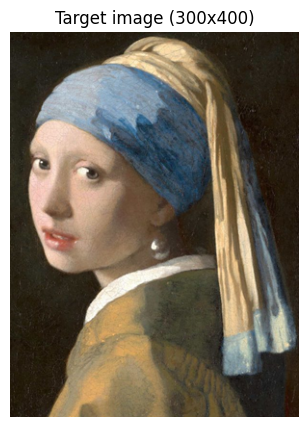

In [7]:

IMAGE_PATH = "/kaggle/working/CIFO_NovaIMS_25-26/girl_pearl_earing.png"
IMG_W, IMG_H    = 300, 400

# Load target image
target = Image.open(IMAGE_PATH).convert("RGBA").resize((IMG_W, IMG_H))
target = np.array(target, dtype=np.float32)  # shape (H, W, 4)

print(f'Image shape: {target.shape}  dtype: {target.dtype}')

# Display target image
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.imshow(target.astype(np.uint8))
ax.set_title('Target image (300x400)')
ax.axis('off')


# Model Implementation: Additional Challenge

In [ ]:
NUM_TRIANGLES   = 100               # number of triangles per individual defined fixed 100
STAGNATION_LIMIT = 100              # limit for stagnation detection, treated as a stopping criterion

In [9]:
NUM_GENERATIONS=20000

In [10]:
random_sol = [random_triangle() for _ in range(100)]

### **Hill-Climbing with Perturbation**

The function receives an initial representative solution and iteratively mutates it via stochastic operators, aiming to minimize the Root Mean Squared Error (RMSE) relative to a reference target matrix (`target_array`).

#### **Neighborhood Exploration Modes**

* **Steepest Ascent (Greedy):** Generates and evaluates a configurable batch of $N$ candidate neighbors (`n_neighbors`) simultaneously, exclusively transitioning to the single candidate that yields the maximum global reduction in error relative to the current state.
* **First Improvement:** Evaluates neighbors sequentially, immediately interrupting the current neighborhood search loop and updating the active state as soon as a candidate that outperforms the current solution is detected.


To avoid possibly getting caught in a **local optimum**, we will experiment with inserting a **random perturbation**. We take the best solution found so far, randomly mutate a large fraction of it (e.g. 30% of triangles get randomized) and then restart hill climbing from this new perturbed point.

Additionally, we make the **number of neighbors evaluated dynamically**, as the number of iterations without improvement grows, we increase the neighborhood size proportionally. This means that the longer the algorithm is stuck, the wider it searches before giving up or restarting, giving it a better chance of finding an escape route before triggering a full perturbation.

Lets dive into these mechanisms:

#### **Perturbation Mechanism** (`perturb_solution`)

To escape local optima, the algorithm utilizes a destructive perturbation step when stagnation is detected. Instead of a complete random restart, it performs a targeted disruption of the current best-known solution:

* **Stochastic Selection:** A subset of elements is isolated based on the `strength` parameter (defaulting to 30% of the total structure).
* **Guaranteed Mutation:** The selected primitives are mutated with a forced probability of $1.0$ via the `mixed_mutation` operator.
* **Preservation:** The remaining structural elements are preserved, maintaining the macroscopic features of the solution while altering fine details.

#### **Dynamic Neighborhood Expansion**
To prevent premature convergence and balance exploitation with exploration, the neighborhood size scales dynamically as exploration stagnates. The number of candidate neighbors generated per iteration, $n_{dyn}$, is modeled as:

$$n_{dyn} = n_{base} \times \left(1 + \left\lfloor \frac{S}{50} \right\rfloor\right)$$

Where $n_{base}$ is the baseline neighborhood size and $S$ represents the continuous iterations without improvement (`stagnation_counter`).

#### **Search Behaviors**
Identical to baseline.


In [11]:
def perturb_solution(solution, mut_method, mut_prob=0.05, strength=0.3):
    """
    Perturbs the solution by applying the mutation method multiple times
    without completely destroying the global structure.
    """
    perturbed = solution.copy()
    # Number of sequential mutation attempts based on strength
    n_mutations = max(1, int(len(perturbed) * strength))
    for _ in range(n_mutations):
        # Pass mut_prob instead of forcing 1.0 to maintain mutation characteristics
        perturbed = mut_method(perturbed, mut_prob=mut_prob)
    return perturbed


def hill_climbing_with_restarts(
    initial_solution,
    target_array,
    max_iterations=5000,
    mut_method=None,
    mut_prob=0.05,
    n_neighbors=10,
    mode="steepest",
    stagnation_limit=300,
    perturbation_strength=0.3,
    max_restarts=5,
    save_every=500, 
    verbose=False,
):
    """
    Hill Climbing with restarts on stagnation and dynamic neighborhood sizing.
    Optimized for image evolution.
    """
    if mut_method is None:
        mut_method = mixed_mutation

    # Normalize target array slice once to save slicing overhead inside loops
    target_rgb = target_array[:, :, :3]

    current = initial_solution.copy()
    current_img = render(current)
    current_rmse = float(np.sqrt(np.mean((current_img[:, :, :3] - target_rgb) ** 2)))

    best_solution = current.copy()
    best_rmse = current_rmse
    history = [current_rmse]

    stagnation_counter = 0
    restart_count = 0

    for it in range(1, max_iterations + 1):
        improved = False

        # Dynamic neighborhood scaling during stagnation
        dynamic_n = n_neighbors * (1 + stagnation_counter // 50)

        if mode == "steepest":
            best_neighbor_solution = None
            best_neighbor_rmse = current_rmse

            for _ in range(dynamic_n):
                candidate = mut_method(current.copy(), mut_prob)
                candidate_img = render(candidate)
                candidate_rmse = float(np.sqrt(np.mean((candidate_img[:, :, :3] - target_rgb) ** 2)))
                
                if candidate_rmse < best_neighbor_rmse:
                    best_neighbor_rmse = candidate_rmse
                    best_neighbor_solution = candidate

            if best_neighbor_solution is not None:
                current = best_neighbor_solution.copy()
                current_rmse = best_neighbor_rmse
                improved = True

        elif mode == "first_improvement":
            for _ in range(dynamic_n):
                neighbor = mut_method(current.copy(), mut_prob)
                neighbor_img = render(neighbor)
                neighbor_rmse = float(np.sqrt(np.mean((neighbor_img[:, :, :3] - target_rgb) ** 2)))
                
                if neighbor_rmse < current_rmse:
                    current = neighbor.copy()
                    current_rmse = neighbor_rmse
                    improved = True
                    break  # Found a better neighbor, stop searching immediately
        else:
            raise ValueError(f"Unknown mode: {mode}. Use 'steepest' or 'first_improvement'.")

        # Update global best tracking
        if current_rmse < best_rmse:
            best_rmse = current_rmse
            best_solution = current.copy()

        history.append(current_rmse)

        # Track stagnation
        if improved:
            stagnation_counter = 0
        else:
            stagnation_counter += 1

        # Check for stagnation / Restart trigger
        if stagnation_counter >= stagnation_limit:
            if restart_count >= max_restarts:
                if verbose:
                    print(f"\n[Early Stop] Max restarts ({max_restarts}) reached at iteration {it}.")
                break

            restart_count += 1
            if verbose:
                print(f"\n[Restart {restart_count}/{max_restarts}] Stagnation reached at iter {it} | Best Global RMSE: {best_rmse:.4f}")

            # Soft-restart from the best historical solution found so far
            current = perturb_solution(best_solution, mut_method, mut_prob, strength=perturbation_strength)
            current_img = render(current)
            current_rmse = float(np.sqrt(np.mean((current_img[:, :, :3] - target_rgb) ** 2)))
            stagnation_counter = 0

        # Diagnostics Console Logging
        if verbose and it % 100 == 0:
            print(f"Iteration {it:04d} | Current RMSE: {current_rmse:.4f} | Best: {best_rmse:.4f} | "
                  f"Neighbors: {dynamic_n} | Restarts: {restart_count}")

        # Image Disk Saving
        if save_every and it % save_every == 0:
            img = render(best_solution)
            os.makedirs("output_hc", exist_ok=True)
            # Clip values to valid image range before casting to uint8 to avoid overflow artifacts
            img_to_save = np.clip(img, 0, 255).astype(np.uint8)
            plt.imsave(f"output_hc/hc_iter_{it:05d}.png", img_to_save)

    return best_solution, history

### Random Parameter Search


── Trial 1/20  |  {'MUT_PROB': 0.2, 'N_NEIGHBORS': 10, 'MODE': 'first_improvement', 'STAGNATION_LIMIT': 300, 'PERTURBATION_STRENGTH': 0.5, 'MAX_RESTARTS': 5, 'MUT_WEIGHTS': [0.05, 0.05, 0.35, 0.25, 0.05, 0.05, 0.05, 0.05, 0.1]}
   Run 1/30
   Run 2/30
   Run 3/30
   Run 4/30
   Run 5/30
   Run 6/30
   Run 7/30
   Run 8/30
   Run 9/30
   Run 10/30
   Run 11/30
   Run 12/30
   Run 13/30
   Run 14/30
   Run 15/30
   Run 16/30
   Run 17/30
   Run 18/30
   Run 19/30
   Run 20/30
   Run 21/30
   Run 22/30
   Run 23/30
   Run 24/30
   Run 25/30
   Run 26/30
   Run 27/30
   Run 28/30
   Run 29/30
   Run 30/30
   Final RMSE: 51.2453  |  Best RMSE: 51.2453  |  (Trial 1/20)

── Trial 2/20  |  {'MUT_PROB': 0.2, 'N_NEIGHBORS': 10, 'MODE': 'steepest', 'STAGNATION_LIMIT': 500, 'PERTURBATION_STRENGTH': 0.2, 'MAX_RESTARTS': 10, 'MUT_WEIGHTS': [0.35, 0.3, 0.0, 0.0, 0.0, 0.15, 0.05, 0.05, 0.1]}
   Run 1/30
   Run 2/30
   Run 3/30
   Run 4/30
   Run 5/30
   Run 6/30
   Run 7/30
   Run 8/30
   Run 9/30
  

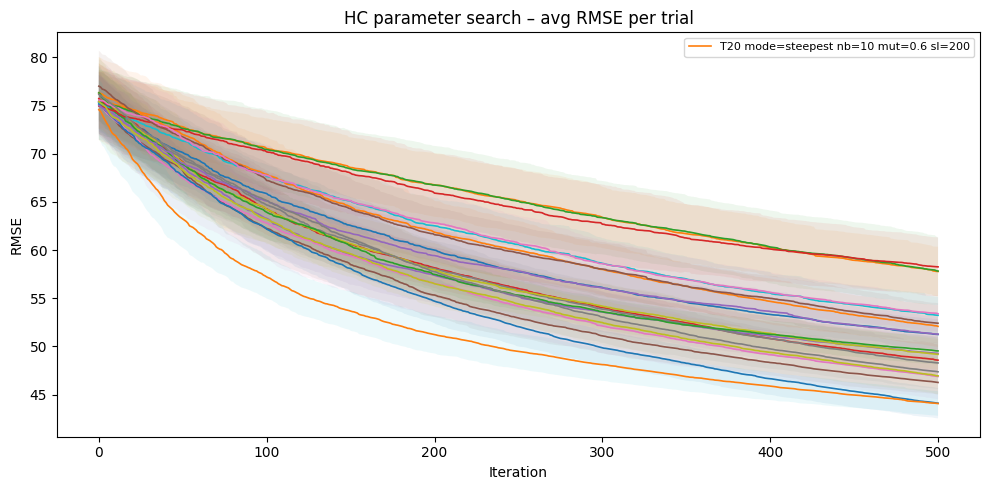


Rendering and displaying the best overall individual across all trials:
Best overall image saved to: output_hc_search/best_overall_solution.png


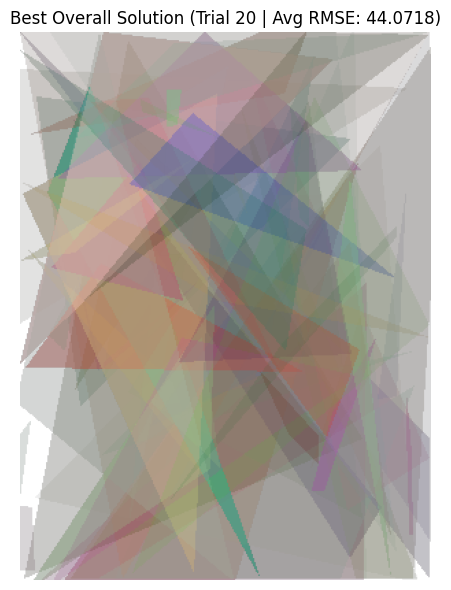

In [12]:
# ── Hill Climbing – Random Parameter Search ──────────────────────────────────

SEARCH_ITERATIONS  = 500   # max HC iterations per run
N_TRIALS           = 20     # number of sampled configs
RUNS_PER_TRIAL     = 30     # independent runs per config (HC is stochastic via perturbation)

# Mutation weight presets
MUT_WEIGHTS_SPACE = [
    # baseline
    [0.15, 0.15, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10],
    # color_soft + color_hard + alpha
    [0.30, 0.05, 0.05, 0.30, 0.05, 0.15, 0.05, 0.05, 0.00],
    # creep + grow + shrink + translate
    [0.05, 0.25, 0.05, 0.05, 0.05, 0.05, 0.20, 0.20, 0.10],
    # triangle_replacement + color_hard
    [0.05, 0.05, 0.35, 0.25, 0.05, 0.05, 0.05, 0.05, 0.10],
    # color_soft + creep + alpha
    [0.35, 0.30, 0.00, 0.00, 0.00, 0.15, 0.05, 0.05, 0.10],
]

# Parameter space
param_space = {
    # mutation probability per triangle
    "MUT_PROB": [0.2, 0.6, 0.4],

    # base number of neighbours evaluated per iteration
    "N_NEIGHBORS": [5, 10, 20],

    # HC variant
    "MODE": ["steepest", "first_improvement"],

    # iterations without improvement before perturbing
    "STAGNATION_LIMIT": [100, 200, 300, 500],

    # fraction of triangles randomly replaced on restart
    "PERTURBATION_STRENGTH": [0.1, 0.2, 0.3, 0.5],

    # how many restarts are allowed before early stop
    "MAX_RESTARTS": [3, 5, 10],

    # weights given to specific mutations
    "MUT_WEIGHTS": MUT_WEIGHTS_SPACE,
}


# Helpers 
def sample_params(space):
    return {k: random.choice(v) for k, v in space.items()}


def make_key(p):
    return tuple(
        p[k].__name__ if callable(p[k]) else
        tuple(p[k])   if isinstance(p[k], list) else
        p[k]
        for k in p
    )


# Sample N unique configs 
sampled = []
seen    = set()
while len(sampled) < N_TRIALS:
    p   = sample_params(param_space)
    key = make_key(p)
    if key not in seen:
        seen.add(key)
        sampled.append(p)


# Storage
best_dnas      = []
avg_histories  = []
std_histories  = []
avg_final_rmse = []
avg_best_rmse  = []
all_params     = []

run_history_records = []
avg_history_records = []

# output directories
os.makedirs("output_hc_search", exist_ok=True)
os.makedirs("output_hc_search/trial_bests", exist_ok=True)


# ── Main search loop 
for i, params in enumerate(sampled):

    print(f"\n── Trial {i+1}/{N_TRIALS}  |  {params}")

    run_histories = []

    best_overall_dna  = None
    best_overall_rmse = float("inf")

    for run in range(RUNS_PER_TRIAL):

        print(f"   Run {run+1}/{RUNS_PER_TRIAL}")

        initial_solution = random_individual()   

        mut_method = partial(mixed_mutation, weights=params["MUT_WEIGHTS"])

        best_dna, history = hill_climbing_with_restarts(
            initial_solution     = initial_solution,
            target_array         = target,
            max_iterations       = SEARCH_ITERATIONS,
            mut_method           = mut_method,
            mut_prob             = params["MUT_PROB"],
            n_neighbors          = params["N_NEIGHBORS"],
            mode                 = params["MODE"],
            stagnation_limit     = params["STAGNATION_LIMIT"],
            perturbation_strength= params["PERTURBATION_STRENGTH"],
            max_restarts         = params["MAX_RESTARTS"],
            verbose              = False,
        )

        run_histories.append(history)

        run_best_rmse  = float(np.min(history))
        run_final_rmse = float(history[-1])

        if run_best_rmse < best_overall_rmse:
            best_overall_rmse = run_best_rmse
            best_overall_dna  = best_dna

        # per-run records 
        for it_idx, rmse in enumerate(history):
            run_history_records.append({
                "trial"              : i + 1,
                "run"                : run + 1,
                "iteration"          : it_idx,
                "rmse"               : float(rmse),
                "run_best_rmse"      : run_best_rmse,
                "run_final_rmse"     : run_final_rmse,
                # params
                "MUT_PROB"           : params["MUT_PROB"],
                "N_NEIGHBORS"        : params["N_NEIGHBORS"],
                "MODE"               : params["MODE"],
                "STAGNATION_LIMIT"   : params["STAGNATION_LIMIT"],
                "PERTURBATION_STRENGTH": params["PERTURBATION_STRENGTH"],
                "MAX_RESTARTS"       : params["MAX_RESTARTS"],
                "MUT_WEIGHTS"        : str(params["MUT_WEIGHTS"]),
            })

    # average across runs 
    max_len = max(len(h) for h in run_histories)
    padded  = [h + [h[-1]] * (max_len - len(h)) for h in run_histories]

    run_arr     = np.array(padded)
    avg_history = np.mean(run_arr, axis=0)
    std_history = np.std (run_arr, axis=0)

    for it_idx, rmse in enumerate(avg_history):
        avg_history_records.append({
            "trial"              : i + 1,
            "iteration"          : it_idx,
            "avg_rmse"           : float(rmse),
            "std_rmse"           : float(std_history[it_idx]),
            # params
            "MUT_PROB"           : params["MUT_PROB"],
            "N_NEIGHBORS"        : params["N_NEIGHBORS"],
            "MODE"               : params["MODE"],
            "STAGNATION_LIMIT"   : params["STAGNATION_LIMIT"],
            "PERTURBATION_STRENGTH": params["PERTURBATION_STRENGTH"],
            "MAX_RESTARTS"       : params["MAX_RESTARTS"],
            "MUT_WEIGHTS"        : str(params["MUT_WEIGHTS"]),
        })

    avg_histories.append(avg_history)
    std_histories.append(std_history)
    avg_final_rmse.append(float(avg_history[-1]))
    avg_best_rmse .append(float(np.min(avg_history)))

    best_dnas.append(best_overall_dna)
    all_params.append(params)

    print(
        f"   Final RMSE: {avg_history[-1]:.4f}  |  "
        f"Best RMSE: {float(np.min(avg_history)):.4f}  |  "
        f"(Trial {i+1}/{N_TRIALS})"
    )
    
    # Render and Save best image from this trial
    if best_overall_dna is not None:
        trial_img = render(best_overall_dna)
        trial_img_clipped = np.clip(trial_img, 0, 255).astype(np.uint8)
        plt.imsave(f"output_hc_search/trial_bests/best_trial_{i+1}.png", trial_img_clipped)


# Best overall result 
best_idx    = int(np.argmin(avg_best_rmse))
best_params = all_params[best_idx]

print(f"\nBest configuration (trial {best_idx + 1}):")
for k, v in best_params.items():
    print(f"   {k}: {v}")
print(f"   Best avg RMSE: {avg_best_rmse[best_idx]:.4f}")


# Save CSVs 
df_history = pd.DataFrame(run_history_records)
df_history.to_csv("hc_search_history.csv", index=False)

df_avg = pd.DataFrame(avg_history_records)
df_avg.to_csv("hc_avg_histories.csv", index=False)

print("\nCSVs saved: hc_search_history.csv  |  hc_avg_histories.csv")


# Quick convergence plot 
fig, ax = plt.subplots(figsize=(10, 5))
for i, (avg_h, std_h, p) in enumerate(zip(avg_histories, std_histories, all_params)):
    label = (
        f"T{i+1} mode={p['MODE']} nb={p['N_NEIGHBORS']} "
        f"mut={p['MUT_PROB']} sl={p['STAGNATION_LIMIT']}"
    )
    xs = range(len(avg_h))
    ax.plot(xs, avg_h, linewidth=1.2,
            color=("tab:orange" if i == best_idx else None),
            label=label if i == best_idx else "_nolegend_",
            zorder=3 if i == best_idx else 2)
    ax.fill_between(xs,
                    np.array(avg_h) - np.array(std_h),
                    np.array(avg_h) + np.array(std_h),
                    alpha=0.08,
                    zorder=1)

ax.set_xlabel("Iteration")
ax.set_ylabel("RMSE")
ax.set_title("HC parameter search – avg RMSE per trial")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("output_hc_search/convergence.png", dpi=150)
plt.show()


print("\nRendering and displaying the best overall individual across all trials:")
absolute_best_dna = best_dnas[best_idx]

if absolute_best_dna is not None:
    
    best_img = render(absolute_best_dna)
    best_img_clipped = np.clip(best_img, 0, 255).astype(np.uint8)
    
    
    final_image_path = "output_hc_search/best_overall_solution.png"
    plt.imsave(final_image_path, best_img_clipped)
    print(f"Best overall image saved to: {final_image_path}")
    
    
    plt.figure(figsize=(6, 6))
    plt.imshow(best_img_clipped)
    plt.title(f"Best Overall Solution (Trial {best_idx + 1} | Avg RMSE: {avg_best_rmse[best_idx]:.4f})")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Warning: No valid DNA package found for the absolute best configuration.")

Shapiro-Wilk Normality Test Results:
Trial 1: Data is NOT normally distributed (p=0.0000)
Trial 2: Data is NOT normally distributed (p=0.0000)
Trial 3: Data is NOT normally distributed (p=0.0000)
Trial 4: Data is NOT normally distributed (p=0.0000)
Trial 5: Data is NOT normally distributed (p=0.0000)
Trial 6: Data is NOT normally distributed (p=0.0000)
Trial 7: Data is NOT normally distributed (p=0.0000)
Trial 8: Data is NOT normally distributed (p=0.0000)
Trial 9: Data is NOT normally distributed (p=0.0000)
Trial 10: Data is NOT normally distributed (p=0.0000)
Trial 11: Data is NOT normally distributed (p=0.0000)
Trial 12: Data is NOT normally distributed (p=0.0000)
Trial 13: Data is NOT normally distributed (p=0.0000)
Trial 14: Data is NOT normally distributed (p=0.0000)
Trial 15: Data is NOT normally distributed (p=0.0000)
Trial 16: Data is NOT normally distributed (p=0.0000)
Trial 17: Data is NOT normally distributed (p=0.0000)
Trial 18: Data is NOT normally distributed (p=0.0000)


C:\Users\maris\AppData\Local\Temp\ipykernel_4520\4175917387.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


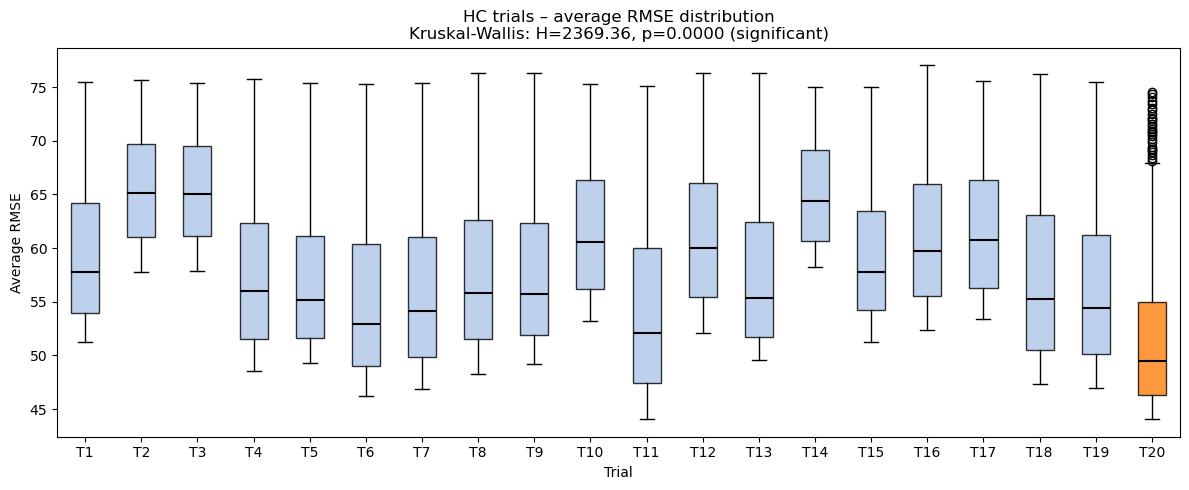

 Significant pairs after Holm correction (adjusted p < 0.05): 
   Trial 1 vs Trial 2 are significantly different (adjusted p=0.0000)
   Trial 1 vs Trial 3 are significantly different (adjusted p=0.0000)
   Trial 1 vs Trial 4 are significantly different (adjusted p=0.0000)
   Trial 1 vs Trial 5 are significantly different (adjusted p=0.0000)
   Trial 1 vs Trial 6 are significantly different (adjusted p=0.0000)
   Trial 1 vs Trial 7 are significantly different (adjusted p=0.0000)
   Trial 1 vs Trial 8 are significantly different (adjusted p=0.0000)
   Trial 1 vs Trial 9 are significantly different (adjusted p=0.0000)
   Trial 1 vs Trial 10 are significantly different (adjusted p=0.0000)
   Trial 1 vs Trial 11 are significantly different (adjusted p=0.0000)
   Trial 1 vs Trial 12 are significantly different (adjusted p=0.0005)
   Trial 1 vs Trial 13 are significantly different (adjusted p=0.0000)
   Trial 1 vs Trial 14 are significantly different (adjusted p=0.0000)
   Trial 1 vs Trial 16

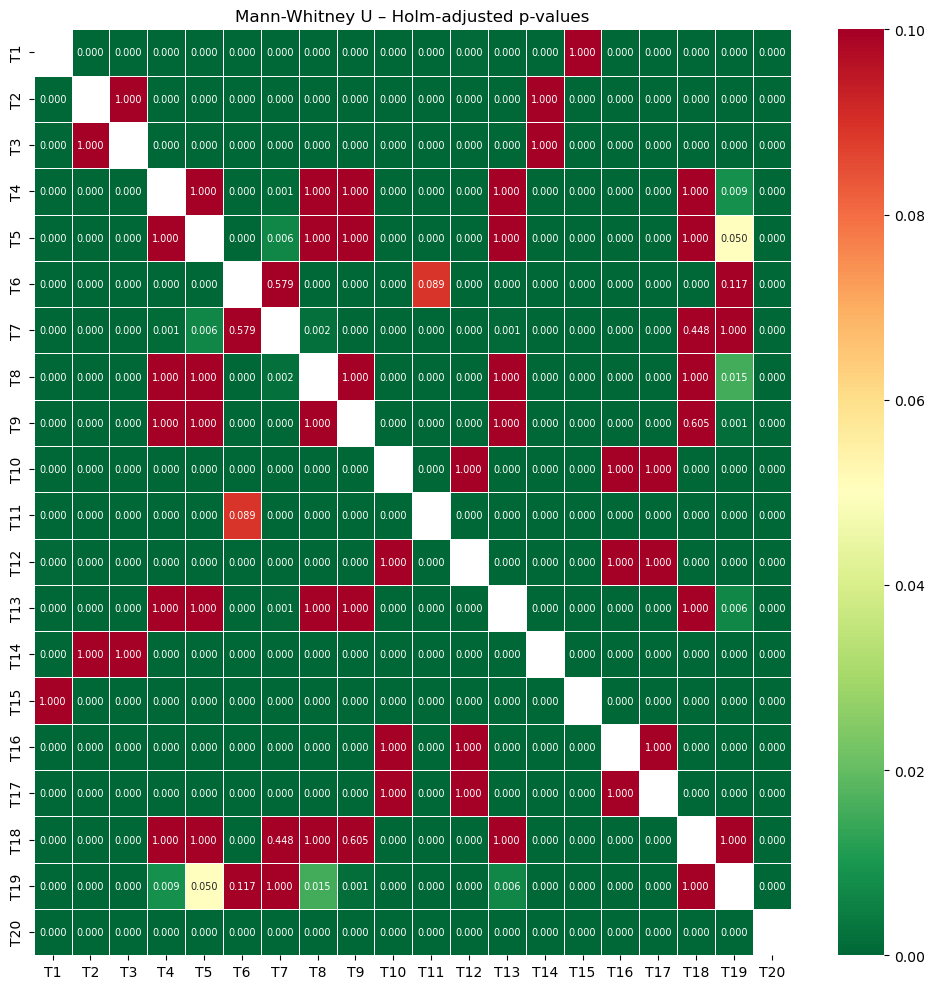

In [ ]:
# ── Statistical Analysis – HC Parameter Search ───────────────────────────────

# Load data and group by trial
avg_df = pd.read_csv("hc_avg_histories.csv")
groups = [group["avg_rmse"].values for _, group in avg_df.groupby("trial")]

# Normality Test----------------------------------------------------------------
normality_results = {}

for trial, group in avg_df.groupby("trial"):
    stat, p_value = stats.shapiro(group["avg_rmse"])
    normality_results[trial] = (stat, p_value)

print("Shapiro-Wilk Normality Test Results:")
for trial, (stat, p_value) in normality_results.items():
    if p_value >= 0.05:
        print(f"Trial {trial}: Data is normally distributed (p={p_value:.4f})")
    else:
        print(f"Trial {trial}: Data is NOT normally distributed (p={p_value:.4f})")

# Kruskal-Wallis Test-----------------------------------------------------------
groups = [group["avg_rmse"].values for _, group in avg_df.groupby("trial")]

stat, p_value = stats.kruskal(*groups)

print(f"\nKruskal-Wallis Test Results: p={p_value:.4f}")
if p_value < 0.05:
    print("There are significant differences between the groups.")
else:
    print("No significant differences found between the groups.")

    # Box Plot-------------------------------------------------------------------
n_trials = len(groups)
trial_numbers = sorted(avg_df["trial"].unique())

best_trial = (
    avg_df.sort_values("iteration")
    .groupby("trial")
    .tail(1)
    .sort_values("avg_rmse")
    .iloc[0]["trial"]
)

fig, ax = plt.subplots(figsize=(max(10, n_trials * 0.6), 5))

bp = ax.boxplot(
    groups,
    labels=[f"T{trial}" for trial in trial_numbers],
    patch_artist=True,
    medianprops=dict(color="black", linewidth=1.5),
)

for trial, patch in zip(trial_numbers, bp["boxes"]):
    patch.set_facecolor("tab:orange" if trial == best_trial else "#aec6e8")
    patch.set_alpha(0.8)

ax.set_xlabel("Trial")
ax.set_ylabel("Average RMSE")
ax.set_title(
    f"HC trials – average RMSE distribution\n"
    f"Kruskal-Wallis: H={stat:.2f}, p={p_value:.4f}"
    + (" (significant)" if p_value < 0.05 else " (not significant)")
)

plt.tight_layout()
plt.show()

#Mann-Whitney U Test with Holmm correction--------------------------------------
pairwise_results = []

for i, j in itertools.combinations(trial_numbers, 2):
    group1 = avg_df[avg_df["trial"] == i]["avg_rmse"]
    group2 = avg_df[avg_df["trial"] == j]["avg_rmse"]
    stat, p_value = stats.mannwhitneyu(group1, group2, alternative='two-sided')
    pairwise_results.append({
    "combination_1": i,
    "combination_2": j,
    "u_statistic": stat,
    "p_value": p_value
})

pairwise_df = pd.DataFrame(pairwise_results)

reject, adjusted_p_values, _, _ = multipletests(pairwise_df["p_value"], method='holm')

pairwise_df["adjusted_p_value"] = adjusted_p_values

print(f" Significant pairs after Holm correction (adjusted p < 0.05): ")
for _, row in pairwise_df.iterrows():
    if row["adjusted_p_value"] < 0.05:
        print(f"   Trial {int(row['combination_1'])} vs Trial {int(row['combination_2'])} are significantly different (adjusted p={row['adjusted_p_value']:.4f})")

# Significance heatmap-------------------------------------------------------
matrix = np.ones((n_trials, n_trials))

trial_to_idx = {trial: idx for idx, trial in enumerate(trial_numbers)}

for _, row in pairwise_df.iterrows():
    a = trial_to_idx[int(row["combination_1"])]
    b = trial_to_idx[int(row["combination_2"])]

    matrix[a, b] = row["adjusted_p_value"]
    matrix[b, a] = row["adjusted_p_value"]

np.fill_diagonal(matrix, np.nan)

fig, ax = plt.subplots(figsize=(max(8, n_trials * 0.5), max(7, n_trials * 0.5)))

sns.heatmap(
    matrix,
    mask=np.isnan(matrix),
    annot=True,
    fmt=".3f",
    cmap="RdYlGn_r",
    vmin=0,
    vmax=0.1,
    linewidths=0.5,
    xticklabels=[f"T{trial}" for trial in trial_numbers],
    yticklabels=[f"T{trial}" for trial in trial_numbers],
    ax=ax,
    annot_kws={"size": 7},
)

ax.set_title("Mann-Whitney U – Holm-adjusted p-values")
plt.tight_layout()
plt.show()

- **Normality:** no trials passed the Shapiro-Wilkin Test, so we used Kruskal-Wallis instead of ANOVA.
- **Kruskal-Wallis:** p~0 means the configurations are not all equivalent. Overall, at least one of our 20 trials has a distribution of values that is significantly different from the others.
- **Post-hoc:** most pairs of groups are highly statistically distinct from one another.

**BoxPlot**

The overall performance profile is dominated by clear sub-groups: trials T2, T3, T10, and T14 exhibit elevated average RMSE distributions with medians consistently above 60, indicating a recurring baseline of poorer performance or higher data variability. Contrariwise, a substantial, interconnected block of trials (including T4–T9, T13, T18, and T19) showcases statistically indistinguishable, so-so error distributions that reflect a plateau. The most pronounced anomalies occur at the operational extremes, highlighted by T11, which registers the lowest median error after T20, which achieves the lowest overall avg RMSE (under 50) but suffers from a dense, severe column of upper-bound outliers reaching up to 75.

**Matrix**

It reveals that the vast majority of the groups possess highly distinct distributions ($p < 0.05$, heavily saturated in green). Despite this widespread statistical divergence, the matrix exposes clear, structurally identical sub-clusters (deep red intersections ($p = 1.000$)), where specific groups behave indistinguishably from one another. Notable cohorts include the tightly coupled pairs of T2 and T3, a larger interconnected block comprising T4, T5, T8, T9, T13, and T18, and a separate distinct cluster formed by T10, T12, T16, and T17. 

In [15]:
hill_solution, hill_history = hill_climbing_with_restarts(
    initial_solution      = best_dnas[best_idx],    
    target_array          = target,
    max_iterations        = NUM_GENERATIONS,
    mut_method            = partial(mixed_mutation, weights=best_params["MUT_WEIGHTS"]),
    mut_prob              = best_params["MUT_PROB"],
    n_neighbors           = best_params["N_NEIGHBORS"],
    mode                  = best_params["MODE"],
    stagnation_limit      = best_params["STAGNATION_LIMIT"],
    perturbation_strength = best_params["PERTURBATION_STRENGTH"],
    max_restarts          = best_params["MAX_RESTARTS"],
    save_every            = 500,
    verbose               = True,
)

Iteration 0100 | Current RMSE: 40.8568 | Best: 40.8568 | Neighbors: 10 | Restarts: 0
Iteration 0200 | Current RMSE: 39.6311 | Best: 39.6311 | Neighbors: 10 | Restarts: 0
Iteration 0300 | Current RMSE: 39.0144 | Best: 39.0144 | Neighbors: 10 | Restarts: 0
Iteration 0400 | Current RMSE: 38.4110 | Best: 38.4110 | Neighbors: 10 | Restarts: 0
Iteration 0500 | Current RMSE: 37.9009 | Best: 37.9009 | Neighbors: 10 | Restarts: 0
Iteration 0600 | Current RMSE: 37.3489 | Best: 37.3489 | Neighbors: 10 | Restarts: 0
Iteration 0700 | Current RMSE: 36.6469 | Best: 36.6469 | Neighbors: 10 | Restarts: 0
Iteration 0800 | Current RMSE: 36.2533 | Best: 36.2533 | Neighbors: 10 | Restarts: 0
Iteration 0900 | Current RMSE: 35.3155 | Best: 35.3155 | Neighbors: 10 | Restarts: 0
Iteration 1000 | Current RMSE: 34.0535 | Best: 34.0535 | Neighbors: 10 | Restarts: 0
Iteration 1100 | Current RMSE: 33.3003 | Best: 33.3003 | Neighbors: 10 | Restarts: 0
Iteration 1200 | Current RMSE: 32.7303 | Best: 32.7303 | Neighbor

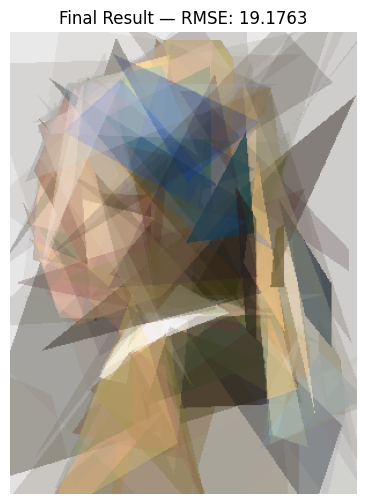

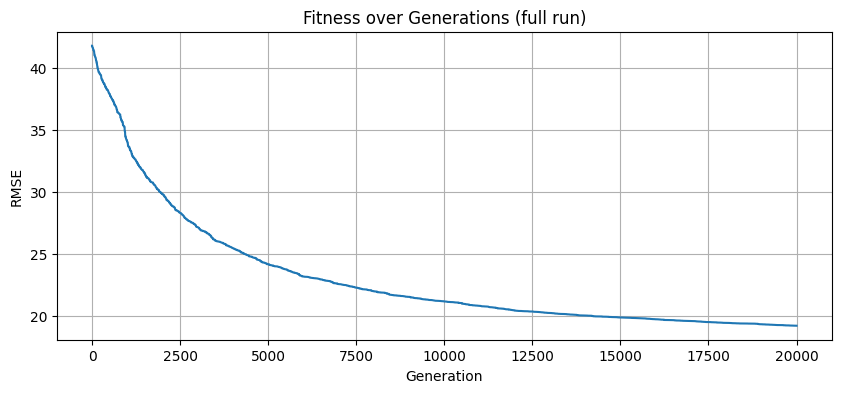

In [16]:
# ── Final Results ─────────────────────────────────────────────────────────

# Final image
plt.figure(figsize=(5, 6))
plt.imshow(render(hill_solution).astype(np.uint8))
plt.title(f"Final Result — RMSE: {hill_history[-1]:.4f}")
plt.axis("off")
plt.show()

# Fitness over generations
plt.figure(figsize=(10, 4))
plt.plot(hill_history)
plt.xlabel("Generation")
plt.ylabel("RMSE")
plt.title("Fitness over Generations (full run)")
plt.grid(True)
plt.show()

